k means clustering

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans

In [13]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [14]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(df)

In [16]:
wcss = []  # within cluster sum of square distance (inertia)
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
wcss

[1000.0,
 297.8954141051723,
 11.57548472310498,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

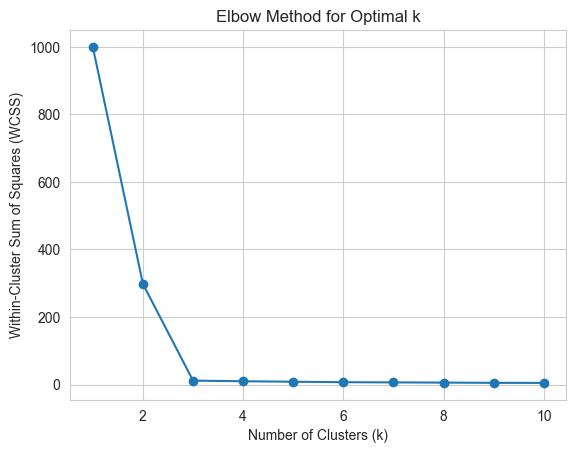

In [17]:
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.show()

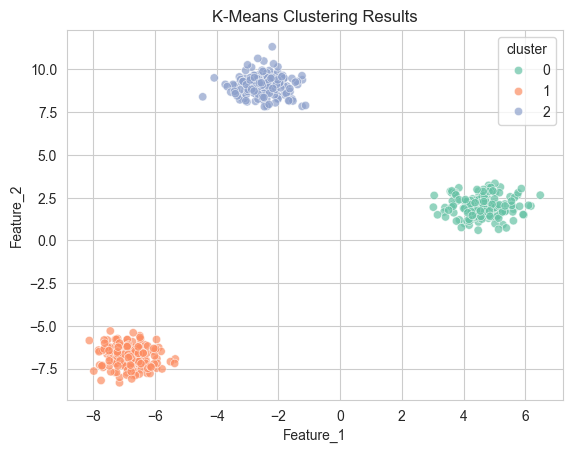

In [18]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['cluster'] = cluster_labels
sns.set_style('whitegrid')
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='cluster', palette='Set2', alpha=0.7)
plt.title('K-Means Clustering Results')
plt.show()

db scan (density based spatial clustering applications with noise) 

In [19]:
from sklearn.datasets import make_moons

In [20]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)  # noise adds some variability to the data

In [21]:
from sklearn.cluster import KMeans, DBSCAN

In [22]:
df1 = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
sc1 = StandardScaler()

In [23]:
X_scaled1 = sc1.fit_transform(df1)

Text(0.5, 1.0, 'K-Means Clustering on Moons Dataset')

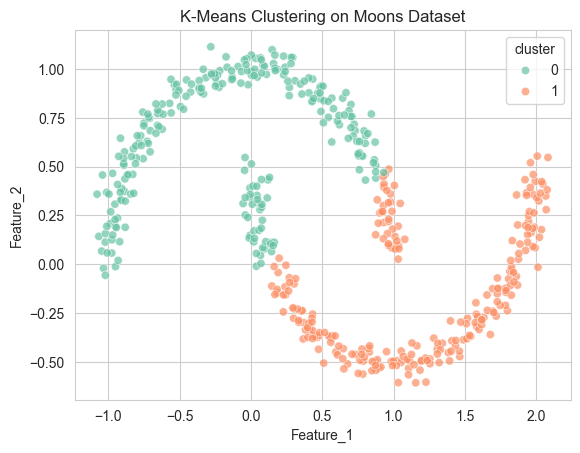

In [24]:
kmeans_model = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_scaled1)
df1['cluster'] = kmeans_labels
sns.set_style('whitegrid')
sns.scatterplot(data=df1, x='Feature_1', y='Feature_2', hue='cluster', palette='Set2', alpha=0.7)
plt.title('K-Means Clustering on Moons Dataset')

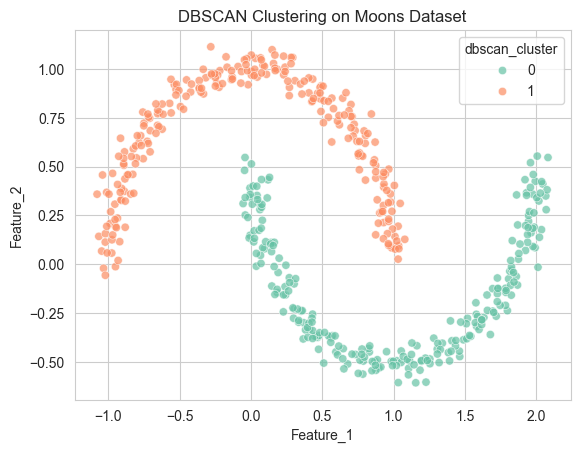

In [26]:
dbscan_model = DBSCAN(eps=0.3, min_samples=5)    # epsilon is the maximum distance between two samples for them to be considered as in the same neighborhood, min_samples is the number of samples in a neighborhood for a point to be considered as a core point
dbscan_labels = dbscan_model.fit_predict(X_scaled1)
df1['dbscan_cluster'] = dbscan_labels
sns.scatterplot(data=df1, x='Feature_1', y='Feature_2', hue='dbscan_cluster', palette='Set2', alpha=0.7)
plt.title('DBSCAN Clustering on Moons Dataset') 
plt.show()